<a href="https://colab.research.google.com/github/aaqibsyed412/AML-Crypto-Project/blob/main/crypto_aml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

path = '/content/drive/MyDrive/aml_project/'

features = pd.read_csv(path + 'elliptic_txs_features.csv', header=None)
classes  = pd.read_csv(path + 'elliptic_txs_classes.csv')

print("features shape:", features.shape)
print("classes shape:", classes.shape)

features shape: (203769, 167)
classes shape: (203769, 2)


In [5]:
features.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [6]:
classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [7]:
classes['class'].value_counts()

,count
class,
unknown,157205
2,42019
1,4545


In [8]:
features = features.rename(columns={0: 'txId', 1: 'time_step'})

In [9]:
features_renamed = features.rename(columns={'txID': 'txId'})
df = features_renamed.merge(classes, on='txId')

print("merged shape:", df.shape)
df.head()

merged shape: (203769, 168)


,txId,time_step,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [10]:
labeled = df[df['class']!='unknown'].copy()
print("labeled shape:", labeled.shape)
print(labeled['class'].value_counts())

labeled shape: (46564, 168)
class
2    42019
1     4545
Name: count, dtype: int64


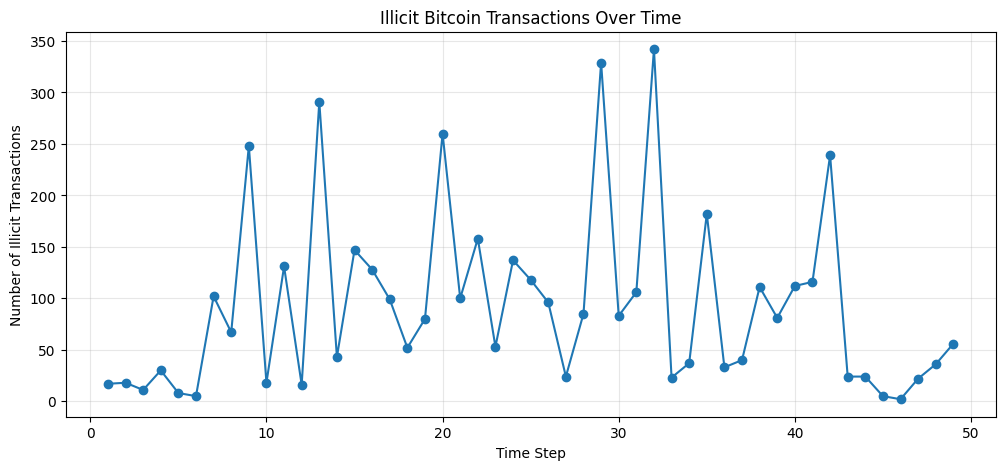

In [11]:
import matplotlib.pyplot as plt

illicit = labeled[labeled['class'] == '1']
illicit_over_time = illicit.groupby('time_step').size()

plt.figure(figsize=(12, 5))
plt.plot(illicit_over_time.index, illicit_over_time.values, marker='o')
plt.title('Illicit Bitcoin Transactions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Number of Illicit Transactions')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

feature_cols = [c for c in labeled.columns if c not in ['txId', 'class']]
X = labeled[feature_cols]
y = labeled['class']

X.columns = X.columns.astype(str) # Convert all column names to strings

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("train:", X_train.shape, " test:", X_test.shape)

train: (32594, 166)  test: (13970, 166)


In [18]:
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           1       0.45      0.93      0.61      1364
           2       0.99      0.88      0.93     12606

    accuracy                           0.88     13970
   macro avg       0.72      0.91      0.77     13970
weighted avg       0.94      0.88      0.90     13970



In [19]:
train_time = labeled[labeled['time_step'] <= 34]
test_time  = labeled[labeled['time_step'] >  34]

X_train_t = train_time[feature_cols]
y_train_t = train_time['class']
X_test_t  = test_time[feature_cols]
y_test_t  = test_time['class']

print("early (train):", X_train_t.shape, " late (test):", X_test_t.shape)

early (train): (29894, 166)  late (test): (16670, 166)


In [21]:
X_train_t.columns = X_train_t.columns.astype(str) # Convert column names to string
X_test_t.columns = X_test_t.columns.astype(str)   # Convert column names to string

model_t = LogisticRegression(max_iter=2000, class_weight='balanced') # Increased max_iter
model_t.fit(X_train_t, y_train_t)

pred_t = model_t.predict(X_test_t)
print(classification_report(y_test_t, pred_t))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           1       0.19      0.87      0.32      1083
           2       0.99      0.75      0.85     15587

    accuracy                           0.76     16670
   macro avg       0.59      0.81      0.58     16670
weighted avg       0.94      0.76      0.82     16670



In [22]:
model_t = LogisticRegression(max_iter=1000, class_weight='balanced')
model_t.fit(X_train_t, y_train_t)

pred_t = model_t.predict(X_test_t)
print(classification_report(y_test_t, pred_t))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           1       0.19      0.87      0.32      1083
           2       0.99      0.75      0.85     15587

    accuracy                           0.76     16670
   macro avg       0.59      0.81      0.58     16670
weighted avg       0.94      0.76      0.82     16670



In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model_r = LogisticRegression(max_iter=1000, class_weight='balanced')
model_r.fit(X_train_s, y_train)
print("RANDOM SPLIT:")
print(classification_report(y_test, model_r.predict(X_test_s)))

RANDOM SPLIT:
              precision    recall  f1-score   support

           1       0.44      0.93      0.60      1364
           2       0.99      0.87      0.93     12606

    accuracy                           0.88     13970
   macro avg       0.72      0.90      0.76     13970
weighted avg       0.94      0.88      0.90     13970



In [24]:
X_train_ts = scaler.fit_transform(X_train_t)
X_test_ts  = scaler.transform(X_test_t)

model_ts = LogisticRegression(max_iter=1000, class_weight='balanced')
model_ts.fit(X_train_ts, y_train_t)
print("TIME SPLIT:")
print(classification_report(y_test_t, model_ts.predict(X_test_ts)))

TIME SPLIT:
              precision    recall  f1-score   support

           1       0.18      0.88      0.30      1083
           2       0.99      0.73      0.84     15587

    accuracy                           0.74     16670
   macro avg       0.59      0.80      0.57     16670
weighted avg       0.94      0.74      0.80     16670



In [25]:
scaler_r = StandardScaler()
X_train_s = scaler_r.fit_transform(X_train)
X_test_s  = scaler_r.transform(X_test)

model_r = LogisticRegression(max_iter=1000, class_weight='balanced')
model_r.fit(X_train_s, y_train)
print("RANDOM SPLIT:")
print(classification_report(y_test, model_r.predict(X_test_s)))

RANDOM SPLIT:
              precision    recall  f1-score   support

           1       0.44      0.93      0.60      1364
           2       0.99      0.87      0.93     12606

    accuracy                           0.88     13970
   macro avg       0.72      0.90      0.76     13970
weighted avg       0.94      0.88      0.90     13970



In [26]:
from sklearn.tree import DecisionTreeClassifier

champion = DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=42)
champion.fit(X_train_t, y_train_t)
champ_pred = champion.predict(X_test_t)

print("CHAMPION (one simple rule):")
print(classification_report(y_test_t, champ_pred))

CHAMPION (one simple rule):
              precision    recall  f1-score   support

           1       0.21      0.76      0.32      1083
           2       0.98      0.80      0.88     15587

    accuracy                           0.79     16670
   macro avg       0.59      0.78      0.60     16670
weighted avg       0.93      0.79      0.84     16670



In [27]:
print("CHALLENGER (your logistic regression):")
print(classification_report(y_test_t, model_ts.predict(X_test_ts)))

CHALLENGER (your logistic regression):
              precision    recall  f1-score   support

           1       0.18      0.88      0.30      1083
           2       0.99      0.73      0.84     15587

    accuracy                           0.74     16670
   macro avg       0.59      0.80      0.57     16670
weighted avg       0.94      0.74      0.80     16670



In [28]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

challenger_pred = model_ts.predict(X_test_ts)
y_true = np.array(y_test_t)

champ_right = (champ_pred == y_true)
chall_right = (challenger_pred == y_true)

champ_only = np.sum(champ_right & ~chall_right)
chall_only = np.sum(~champ_right & chall_right)

table = [[0, champ_only], [chall_only, 0]]
result = mcnemar(table, exact=False, correction=True)
print(f"Champion right, challenger wrong: {champ_only}")
print(f"Challenger right, champion wrong: {chall_only}")
print(f"p-value: {result.pvalue}")

Champion right, challenger wrong: 2231
Challenger right, champion wrong: 1292
p-value: 2.9546399004425036e-56


In [29]:
!pip install statsmodels

In [31]:
print(type(champ_pred))
print(type(challenger_pred))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
